<a href="https://colab.research.google.com/github/Luis-GCH/IA_1994989/blob/main/FFNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 5.- Artificial Neural Network: feedforward.
### Class time: 1, 3, 5 - N1

Olga Regina Charles Moreno / 2049291

Luis Gerardo Cordova Herrera / 1994989

Evelyn Regina Espinoza Tamez / 2049451

Luis Fernando Rivera Peregrino / 2132271




In [21]:
# Load libraries

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

In [22]:
# Load data

# Load MNIST dataset
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

# Display dataset shapes
print("Training data shape:", train_data.shape)
print("Training labels shape:", train_labels.shape)

print("Test data shape:", test_data.shape)
print("Test labels shape:", test_labels.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


In [23]:
# Data preprocessing

# Normalize pixel values between 0 and 1
train_data = train_data / 255.0
test_data = test_data / 255.0

# Convert labels to categorical format
train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

In [24]:
# Model selection and training

# Create Feedforward Neural Network model, in this case we chose sequential
model = Sequential()

# Flatten 28x28 images into a vector
model.add(Flatten(input_shape=(28, 28)))

# Hidden layers aside from Flatten are Dense
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

# Output layer with softmax activation
model.add(Dense(10, activation='softmax'))

# Compile the model with the adam optimizer, categorical_crossentropy
# loss function, and accuracy to evaluate training process
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
# Train the model with the "fit" function

history = model.fit(
    train_data,
    train_labels,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9196 - loss: 0.2719 - val_accuracy: 0.9595 - val_loss: 0.1365
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9659 - loss: 0.1137 - val_accuracy: 0.9602 - val_loss: 0.1334
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9750 - loss: 0.0784 - val_accuracy: 0.9706 - val_loss: 0.1053
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9820 - loss: 0.0574 - val_accuracy: 0.9742 - val_loss: 0.0928
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9843 - loss: 0.0465 - val_accuracy: 0.9699 - val_loss: 0.1095
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9877 - loss: 0.0375 - val_accuracy: 0.9748 - val_loss: 0.0920
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9898 - loss: 0.0293 - val_accuracy: 0.9777 - val_loss: 0.0885
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9912 - loss: 0.0271 

In [26]:
# Model testing
# Evaluate the model with test dataset

test_loss, test_accuracy = model.evaluate(test_data, test_labels)

print("\nTest Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9772 - loss: 0.0998

Test Accuracy: 0.9771999716758728
Test Loss: 0.09975292533636093


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Image 1
Predicted value: 7
Actual value: 7


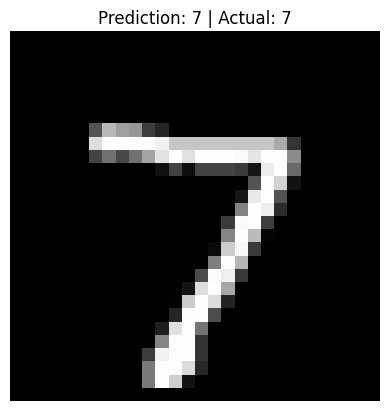


Image 2
Predicted value: 2
Actual value: 2


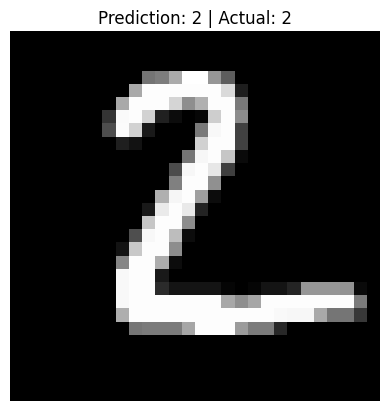


Image 3
Predicted value: 1
Actual value: 1


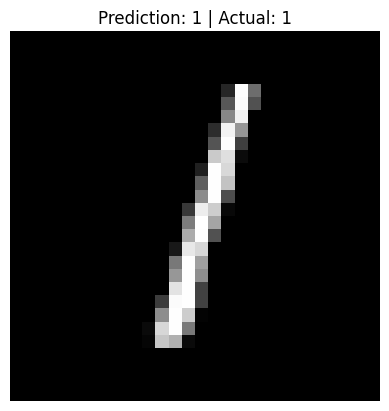


Image 4
Predicted value: 0
Actual value: 0


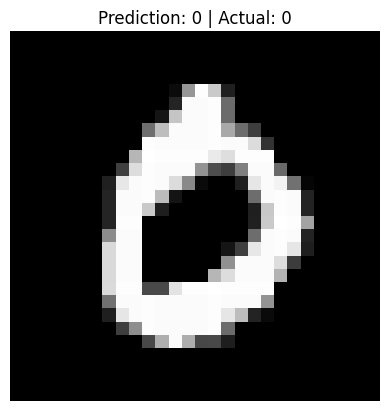


Image 5
Predicted value: 4
Actual value: 4


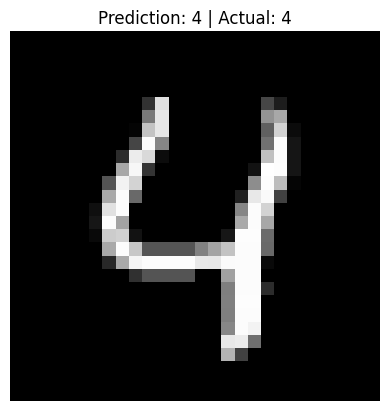

In [27]:
# Perform 5 predictions

predictions = model.predict(test_data)

for i in range(5):

    # Predicted value
    predicted_label = np.argmax(predictions[i])

    # Actual value
    actual_label = np.argmax(test_labels[i])

    print(f"\nImage {i+1}")
    print("Predicted value:", predicted_label)
    print("Actual value:", actual_label)

    # Display results
    plt.imshow(test_data[i], cmap='gray')
    plt.title(f"Prediction: {predicted_label} | Actual: {actual_label}")
    plt.axis('off')
    plt.show()